In [ ]:
# importiing the neccessary libraries
import pandas as pd
import tensorflow as tf

import re
import numpy as np
from string import punctuation
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report ,accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# importing tensor flow and other word processing libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from wordcloud import WordCloud,STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GRU, LSTM, RNN, SpatialDropout1D

In [ ]:
rnews_data= pd.read_csv("650 real news dataset-1.csv")
fnews_data = pd.read_csv("286 fake news dataset_Updated - 286 fake news dataset-1.csv")

In [ ]:
# false news data inspection
fnews_data.head()

,ID,News_title,News_textAuthor,Published_Date,source,site_URL,Author,Country,Language,Other_Sources,Other_URL,News type,Party_affiliated,Location,Region,Subject,Header_image_url,Label
0,1,The posts Urdu-language caption translates to ...,The posts Urdu-language caption translates to ...,9/22/2020,AFP,https://factcheck.afp.com/photo-shows-nawaz-sh...,AFP,Pakistan,English,dunya news,https://dunyanews.tv/en/FakeNews/565782-Nawaz-...,Politics,PMLN,islamabad,PUNJAB,international,https://factcheck.afp.com/sites/default/files/...,fake
1,2,"Sharif, Pakistani longest-serving Prime Minist...","Sharif, Pakistani longest-serving Prime Minist...",1/23/2020,AFP,https://factcheck.afp.com/2017-photo-nawaz-sha...,AFP,Pakistan,English,Fact Check,https://tribune.com.pk/story/2174648/fact-chec...,Politics,PMLN,islamabad,PUNJAB,Democratic,https://factcheck.afp.com/sites/default/files/...,fake
2,3,24 News aires a blatant lie about the meals of...,24 News aires a blatant lie about the meals of...,7/17/2020,24 News,https://www.insaf.pk/fakenewsbuster/24-news-pu...,24 News,Pakistan,English,NaN,NaN,Politics,PTI,islamabad,PUNJAB,cultural,https://www.insaf.pk/sites/default/files/23F.jpg,fake
3,4,Geo News had aired fake news where they claim ...,Geo News had aired fake news where they claim ...,7/17/2020,insaf news,https://www.insaf.pk/fakenewsbuster/fake-news-...,insaf news,Pakistan,English,NaN,NaN,Politics,PTI,islamabad,PUNJAB,Cultural,https://www.insaf.pk/sites/default/files/27F.2...,fake
4,5,"Imran Khan Falls For Fake News, Deletes Tweet ...","Imran Khan Falls For Fake News, Deletes Tweet ...",4/1/2020,boom live,https://www.boomlive.in/fake-news/imran-khan-f...,boom live,Pakistan,English,NaN,NaN,Politics,pti,islamabad,PUNJAB,Cultural,https://www.boomlive.in/h-upload/2020/01/06/82...,fake


In [ ]:
# real news data inspection
rnews_data.head()

In [ ]:
# converting false news and real news columns to integer
rnews_data["Label"] = 1
fnews_data["Label"] = 0

In [ ]:
#data.head()

In [ ]:
# checking the dimension of the both datasets
print(fnews_data.shape)
print(rnews_data.shape)

(285, 18)
(653, 18)


In [ ]:
fnews_data["Author"].value_counts()

soch fact               78
AFP                     68
Soch                    31
Insaf                   11
Twitter                 10
Soch Fact Check         10
Dawn News               10
Dunya News               4
insaf news               4
Dawn                     4
\n@FactCheckerMoIB       4
Global village Space     3
The qunt                 3
newsmeter                3
boom live                3
24 News                  2
The express News         2
TWITTER   FACTCH         2
Times Now News           2
Fack check               2
Techjuice                2
TFIPOST                  2
scroll in                2
World Asia               2
The NAMAL                2
Parhlo                   2
Tribune                  2
Baaghi tv                1
Pro Pakistani            1
The indian express       1
jasarat                  1
incpak                   1
National Herald          1
The logicsal indian      1
The logical indian       1
vishva news              1
unews tv                 1
t

In [ ]:
# checking the false to confirm the value change
fnews_data["Label"].value_counts()

0    285
Name: Label, dtype: int64

In [ ]:
rnews_data["Label"].value_counts()

1    653
Name: Label, dtype: int64

In [ ]:
rnews_data.isnull().sum()

ID                     1
Title                  1
News_Text              1
Published_Date         7
Source                 1
Source_URL             2
Author                 1
country                2
language               1
Other_Source         150
Other_Source_URL     155
News_Type              1
Party_Affiliation     10
Location              31
Region                31
Subject               14
Header_Image_URL     246
Label                  0
dtype: int64

In [ ]:
fnews_data.isnull().sum()

ID                    0
News_title            0
News_textAuthor       1
Published_Date        1
source                2
site_URL              1
Author                2
Country               0
Language              0
Other_Sources       104
Other_URL           116
News type             0
Party_affiliated     45
Location             65
Region               73
Subject               0
Header_image_url      5
Label                 0
dtype: int64

In [ ]:
fnews_data

,ID,News_title,News_textAuthor,Published_Date,source,site_URL,Author,Country,Language,Other_Sources,Other_URL,News type,Party_affiliated,Location,Region,Subject,Header_image_url,Label
0,1,The posts Urdu-language caption translates to ...,The posts Urdu-language caption translates to ...,9/22/2020,AFP,https://factcheck.afp.com/photo-shows-nawaz-sh...,AFP,Pakistan,English,dunya news,https://dunyanews.tv/en/FakeNews/565782-Nawaz-...,Politics,PMLN,islamabad,PUNJAB,international,https://factcheck.afp.com/sites/default/files/...,0
1,2,"Sharif, Pakistani longest-serving Prime Minist...","Sharif, Pakistani longest-serving Prime Minist...",1/23/2020,AFP,https://factcheck.afp.com/2017-photo-nawaz-sha...,AFP,Pakistan,English,Fact Check,https://tribune.com.pk/story/2174648/fact-chec...,Politics,PMLN,islamabad,PUNJAB,Democratic,https://factcheck.afp.com/sites/default/files/...,0
2,3,24 News aires a blatant lie about the meals of...,24 News aires a blatant lie about the meals of...,7/17/2020,24 News,https://www.insaf.pk/fakenewsbuster/24-news-pu...,24 News,Pakistan,English,NaN,NaN,Politics,PTI,islamabad,PUNJAB,cultural,https://www.insaf.pk/sites/default/files/23F.jpg,0
3,4,Geo News had aired fake news where they claim ...,Geo News had aired fake news where they claim ...,7/17/2020,insaf news,https://www.insaf.pk/fakenewsbuster/fake-news-...,insaf news,Pakistan,English,NaN,NaN,Politics,PTI,islamabad,PUNJAB,Cultural,https://www.insaf.pk/sites/default/files/27F.2...,0
4,5,"Imran Khan Falls For Fake News, Deletes Tweet ...","Imran Khan Falls For Fake News, Deletes Tweet ...",4/1/2020,boom live,https://www.boomlive.in/fake-news/imran-khan-f...,boom live,Pakistan,English,NaN,NaN,Politics,pti,islamabad,PUNJAB,Cultural,https://www.boomlive.in/h-upload/2020/01/06/82...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,96,7 doctored Aurat March posters,"1. Blank Flyers\n2. Main Awara, Main Badchalan...",11/3/2020,Soch,https://www.sochfactcheck.com/7-doctored-aurat...,Soch,Pakistan,English,Twitter,https://twitter.com/_Mansoor_Ali/status/123672...,Politics,NaN,Karachi,NaN,Democratic,https://www.sochfactcheck.com/wp-content/uploa...,0
281,97,No coronavirus cases have been confirmed in Badin,Claim: A number of people belonging to the Sam...,5/3/2020,Soch,https://www.sochfactcheck.com/no-coronavirus-c...,Soch,Pakistan,English,Facebook,NaN,Politics,NaN,Baddin,Sindh,Democratic,https://www.sochfactcheck.com/wp-content/uploa...,0
282,98,Viral Stories About Locust Eating Duck Army Fr...,CLAIM: Chinese officials are on standby with 1...,2/3/2020,Soch,https://www.sochfactcheck.com/viral-stories-ab...,Soch,Pakistan,English,Dawn,https://www.dawn.com/news/1536988,Politics,PTI,NaN,NaN,International,https://www.sochfactcheck.com/wp-content/uploa...,0
283,99,"Weekend Remains Saturday and Sunday, ZSN News ...","CLAIM: Facebook page, ZSN News, claimed Prime ...",22/1/2020,Soch,https://www.sochfactcheck.com/weekend-remains-...,Soch,Pakistan,English,Facebook,https://www.facebook.com/401413666924830/photo...,Politics,PTI,NaN,NaN,Democratic,https://www.sochfactcheck.com/wp-content/uploa...,0


In [ ]:
# checking the news title
fnews_data["News_title"][1]

'Sharif, Pakistani longest-serving Prime Minister who reigned over three non-consecutive terms, was ousted of power in 2017 and imprisoned on corruption charges.'

In [ ]:
# checking to see if the title of the news appears in the main news
fnews_data["News_textAuthor"][0]

'The posts Urdu-language caption translates to English as : "This is the meeting in which Nawaz Sharif met with the Israeli ambassador and made a deal to take his business to Israel in exchange for Pakistan\'s nuclear secrets. Be reminded that it is the same deal which has been mentioned in the 10th volume of the JIT (Joint Investigation Team) report as evidence'

In [ ]:
rnews_data["News_Text"][0]

"Pakistan's Information Technology Minister Fawad Chaudhry has said that the nation understands difference between interest of Nawaz Sharif and national interest. He said supporters of the ousted prime minister will also have to realize this difference in order to avoid any kind of conflict of interest."

In [ ]:
# since it is not there, then there is need to add the title to the main news since they both predict if a news is fake or not then generating a new variable
fnews_data['news']=fnews_data["News_title"]+fnews_data['News_textAuthor']

In [ ]:
# doing the same thing as explained above here
rnews_data['news'] = rnews_data["News_Text"] + rnews_data["Title"]

In [ ]:
# dropping the previous variables since another news has been generated
rnews_data = rnews_data.drop(["News_Text", 'Title'], axis = 1)

In [ ]:
# doing the same thing as explained above here
fnews_data = fnews_data.drop(['News_title', 'News_textAuthor'], axis =1)

In [ ]:
# inspecting to see changes
fnews_data.head(1)

,ID,Published_Date,source,site_URL,Author,Country,Language,Other_Sources,Other_URL,News type,Party_affiliated,Location,Region,Subject,Header_image_url,Label,news
0,1,9/22/2020,AFP,https://factcheck.afp.com/photo-shows-nawaz-sh...,AFP,Pakistan,English,dunya news,https://dunyanews.tv/en/FakeNews/565782-Nawaz-...,Politics,PMLN,islamabad,PUNJAB,international,https://factcheck.afp.com/sites/default/files/...,0,The posts Urdu-language caption translates to ...


In [ ]:
# changing the names of the real news in preparating for merging with the fake news
rnews_data.columns = ["ID","Published_Date","source","site_URL","Author","Country","Language","Other_Sources" , "Other_URL","News type","Party_affiliated","Location","Region","Subject","Header_image_url","Label","news"]

In [ ]:
# rearranging the column names
rnews_data  = rnews_data[["ID","Published_Date","source","site_URL","Author","Country","Language","Other_Sources", "Other_URL","News type","Party_affiliated","Location","Region","Subject","Header_image_url","news","Label"]]

In [ ]:
fnews_data  = fnews_data[["ID","Published_Date","source","site_URL","Author","Country","Language","Other_Sources", "Other_URL","News type","Party_affiliated","Location","Region","Subject","Header_image_url","news","Label"]]

In [ ]:
# concating as well as generating a new dataset
newsframes = [fnews_data, rnews_data]
news_dataset = pd.concat(newsframes)
news_dataset.columns

Index(['ID', 'Published_Date', 'source', 'site_URL', 'Author', 'Country',
       'Language', 'Other_Sources', 'Other_URL', 'News type',
       'Party_affiliated', 'Location', 'Region', 'Subject', 'Header_image_url',
       'news', 'Label'],
      dtype='object')

In [ ]:
# replacing the index column with as it is not needed
news_dataset = news_dataset.set_index('id', drop = True)

In [ ]:
news_dataset.shape

(938, 17)

In [ ]:
# checking for missing values
news_dataset.isnull().sum()

ID                    1
Published_Date        8
source                3
site_URL              3
Author                3
Country               2
Language              1
Other_Sources       254
Other_URL           271
News type             1
Party_affiliated     55
Location             96
Region              104
Subject              14
Header_image_url    251
news                  2
Label                 0
dtype: int64

In [ ]:
# dropping all the missing values
news_dataset = news_dataset.dropna()

In [ ]:
news_dataset.isnull().sum()

ID                  0
Published_Date      0
source              0
site_URL            0
Author              0
Country             0
Language            0
Other_Sources       0
Other_URL           0
News type           0
Party_affiliated    0
Location            0
Region              0
Subject             0
Header_image_url    0
news                0
Label               0
dtype: int64

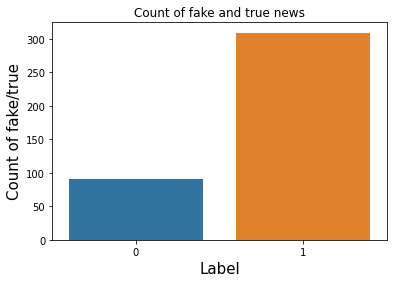

In [ ]:
# Visualising to see the amout of fake news and real news
ax=sns.countplot(x=news_dataset["Label"], data=news_dataset)

#Setting labels and font size
ax.set(xlabel='News Label', ylabel='Count of fake/true',title='Count of fake and true news')
ax.xaxis.get_label().set_fontsize(15)
ax.yaxis.get_label().set_fontsize(15)

In [ ]:
# checking to see the first 20  top 2 focus keywords in the news
def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

In [ ]:
common_words = get_top_n_bigram(news_dataset['news'], 20)

#Printing the word and frequency
for word, freq in common_words:
    print(word, freq)

#Creating the dataframe of word and frequency
words_freq = pd.DataFrame(common_words, columns = ['news' , 'count'])


92 news 232
nawaz sharif 230
prime minister 221
imran khan 192
said that 157
islamabad 92 131
in the 112
of the 112
to the 88
that the 87
maryam nawaz 80
pm imran 72
minister imran 72
he said 61
minister pm 60
khan has 55
news prime 54
lahore 92 53
has been 48
on tuesday 45


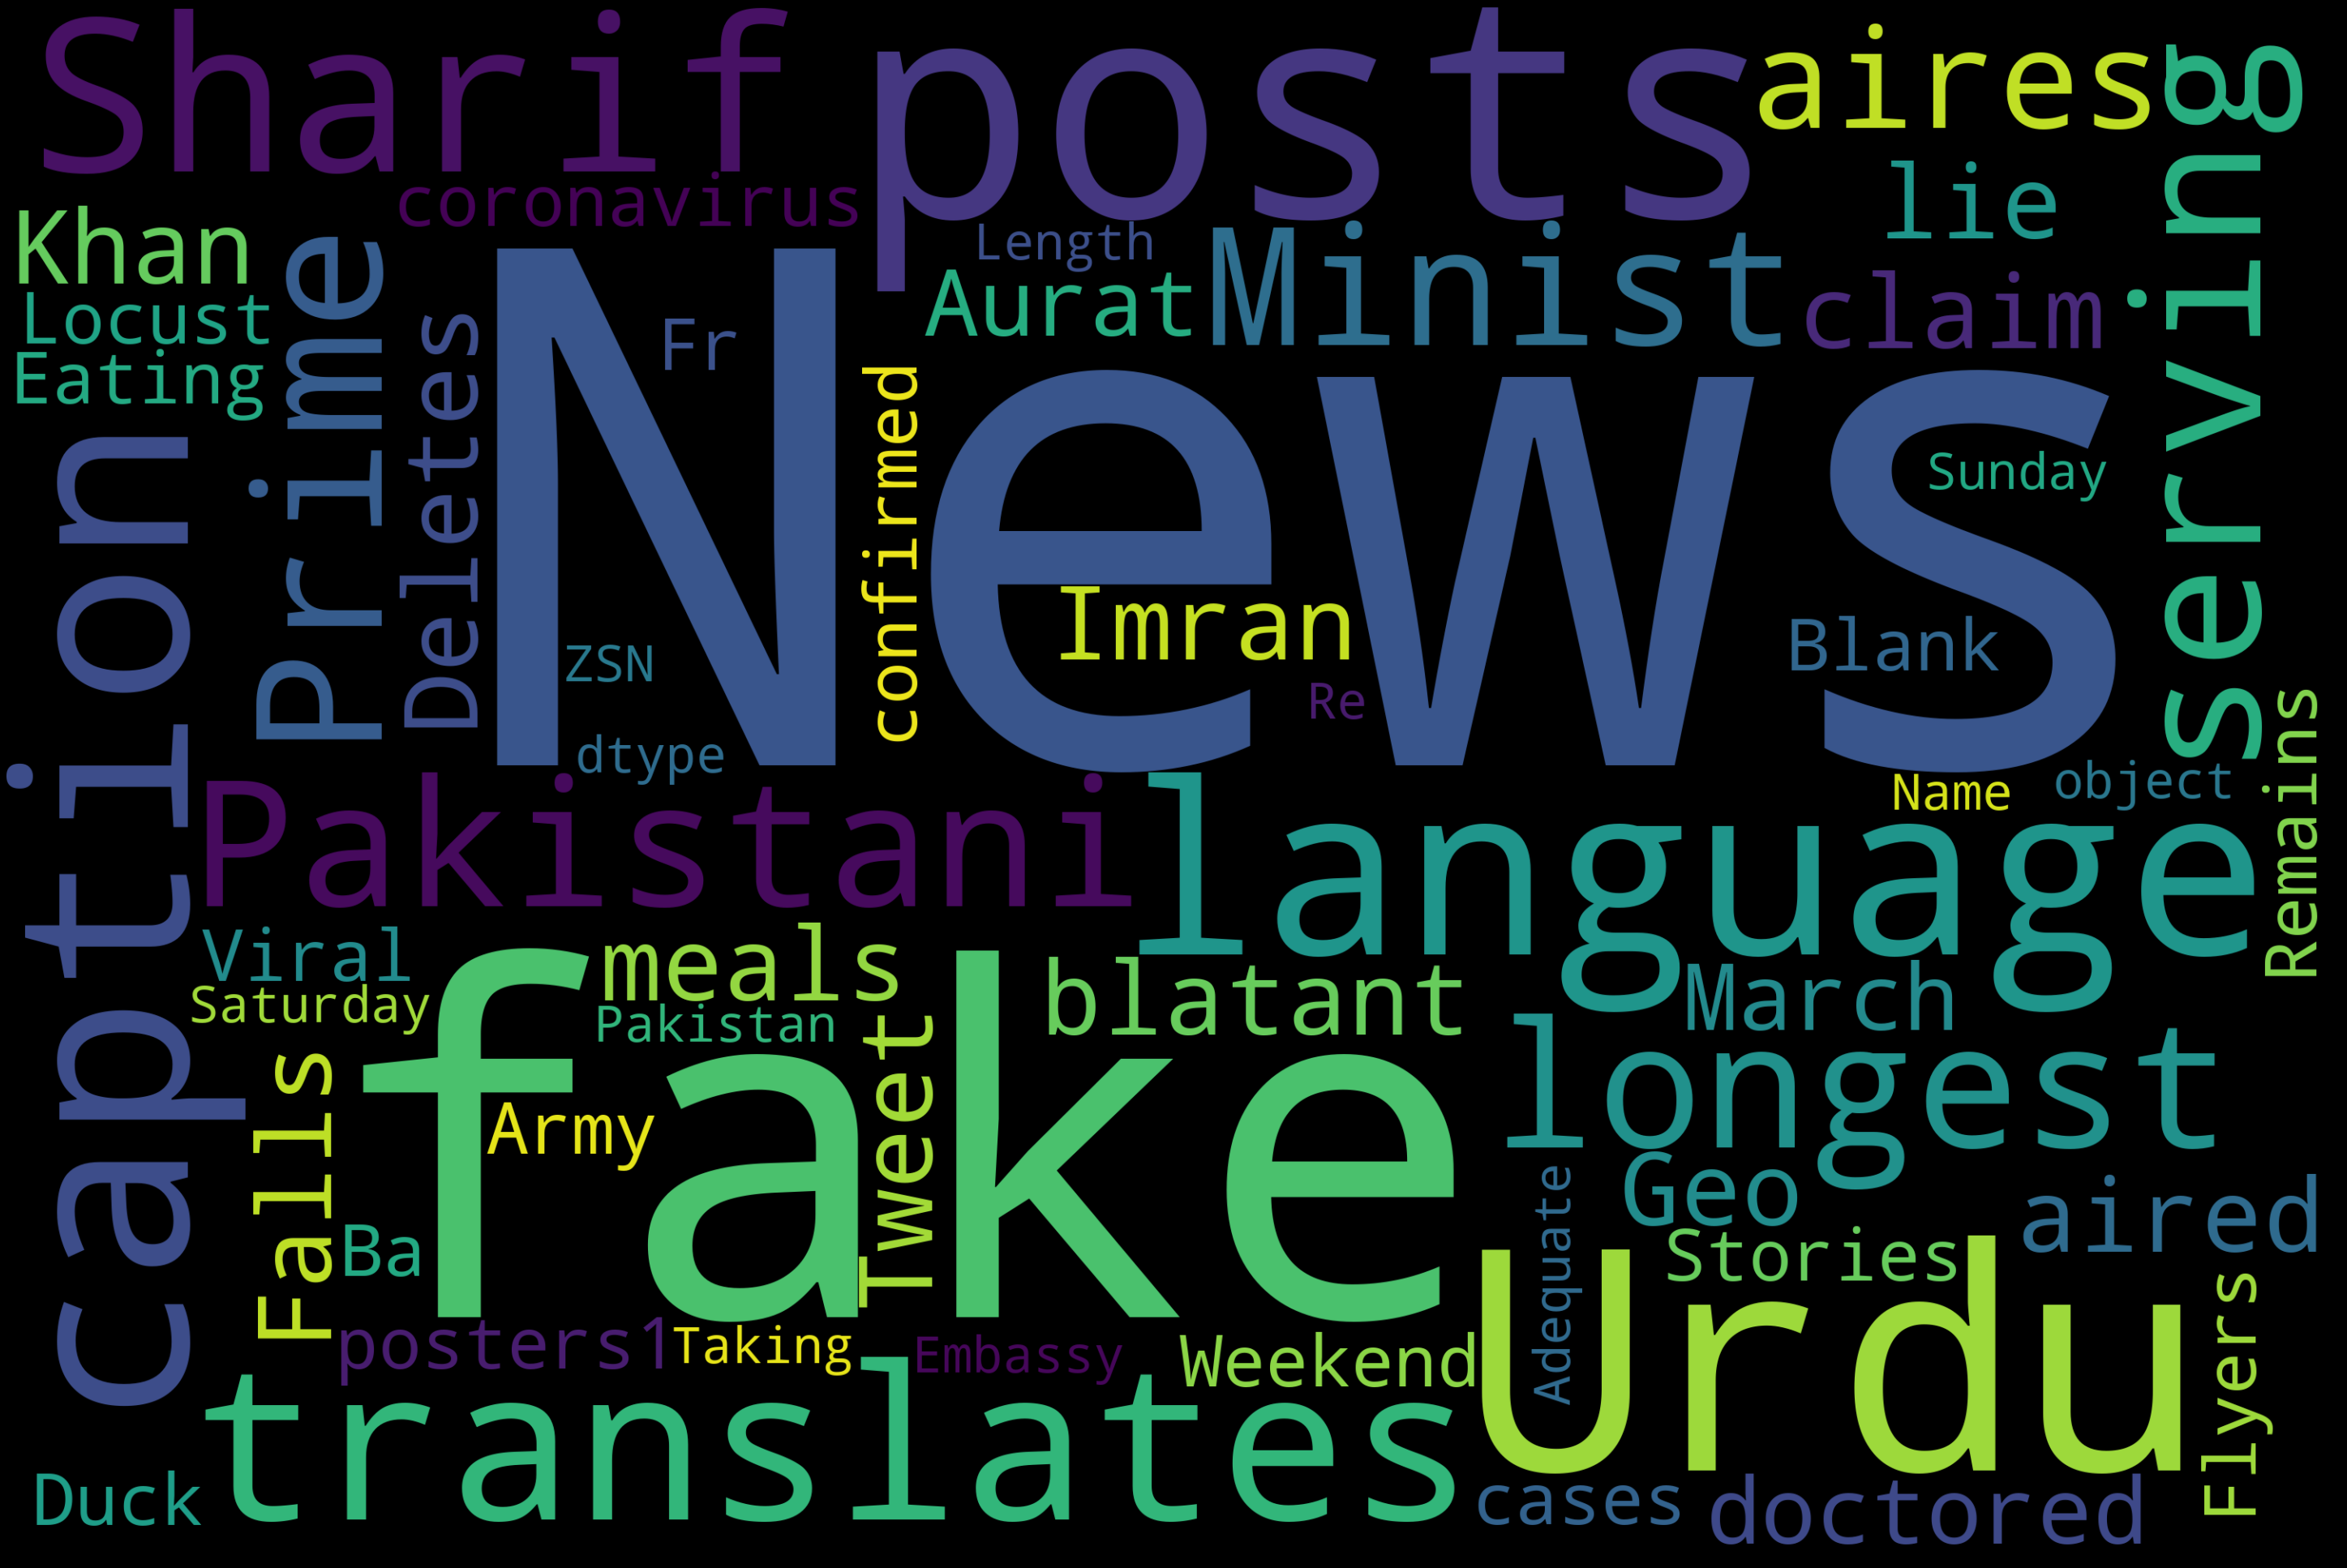

In [ ]:
# checking to see the most occuring word in the fake news
text = fnews_data["news"]
wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'black',
    stopwords = STOPWORDS).generate(str(text))
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

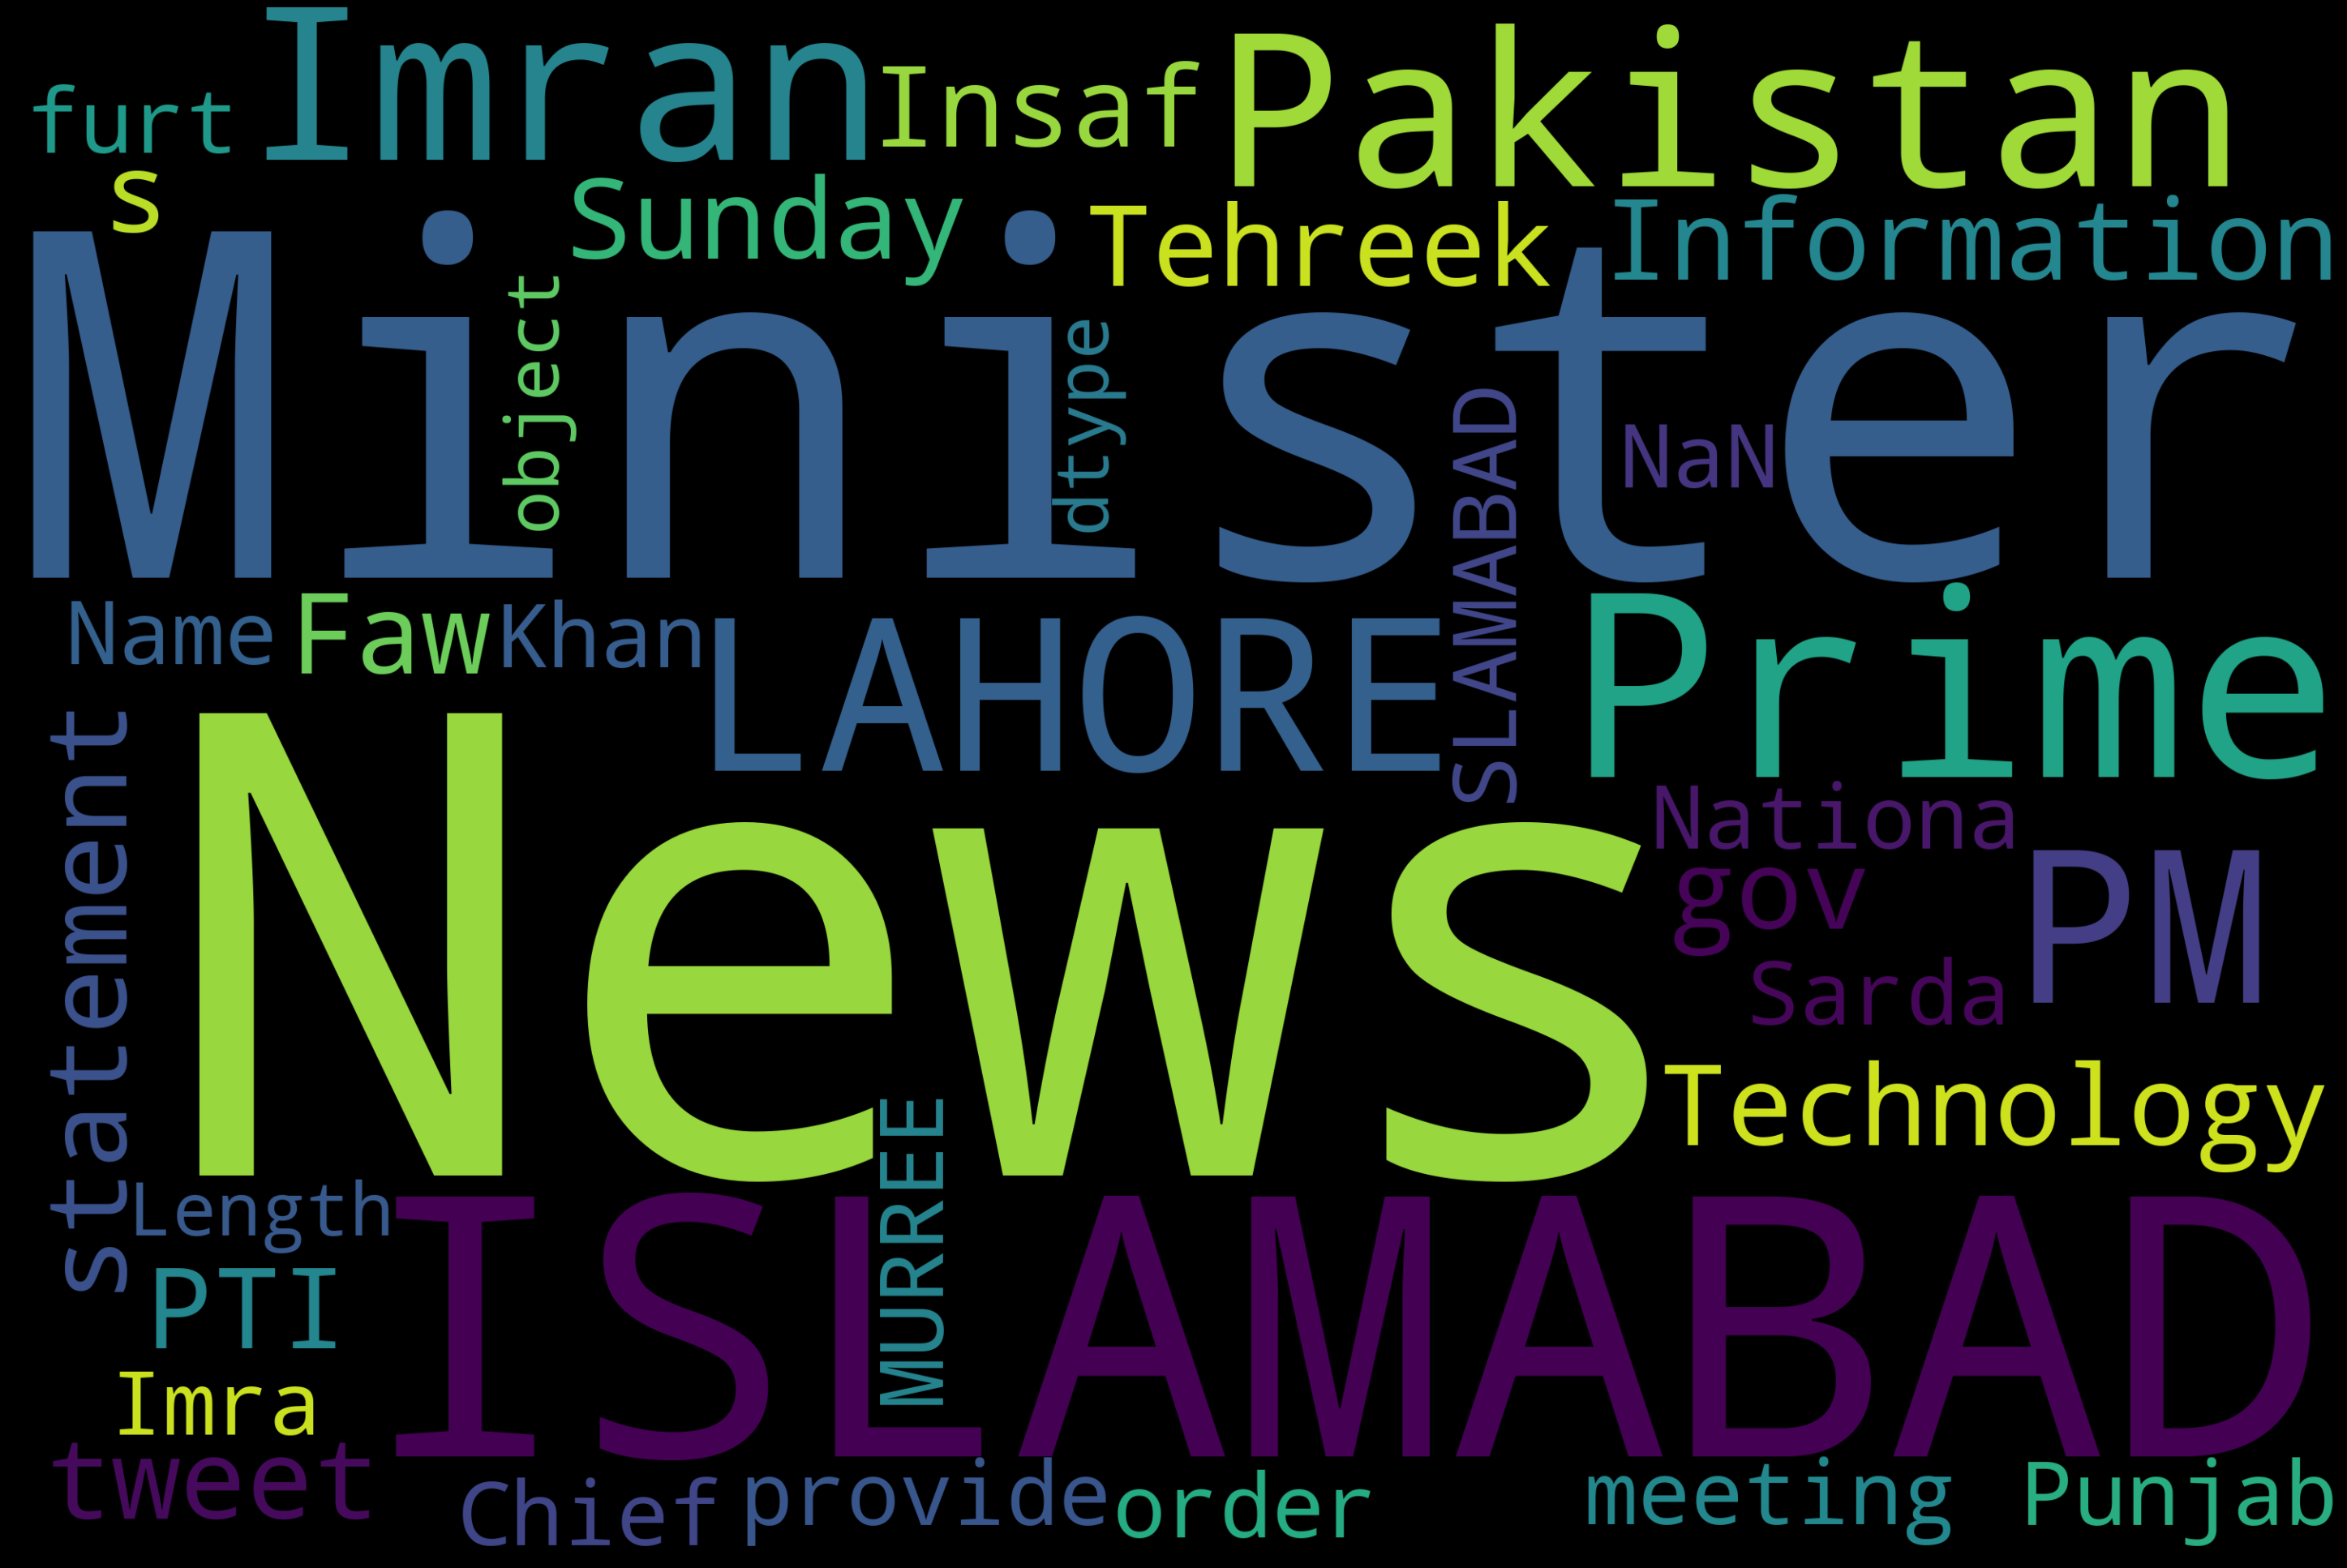

In [ ]:
# checking to see the most occuring word in the real news

text = rnews_data["news"]
wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'black',
    stopwords = STOPWORDS).generate(str(text))
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## Model Building and Preparation

In [ ]:
length = []
[length.append(len(str(text))) for text in news_dataset['news']]
news_dataset['news_length'] = length
news_dataset.head()

,ID,Published_Date,source,site_URL,Author,Country,Language,Other_Sources,Other_URL,News type,Party_affiliated,Location,Region,Subject,Header_image_url,news,Label,news_length
0,1.0,9/22/2020,AFP,https://factcheck.afp.com/photo-shows-nawaz-sh...,AFP,Pakistan,English,dunya news,https://dunyanews.tv/en/FakeNews/565782-Nawaz-...,Politics,PMLN,islamabad,PUNJAB,international,https://factcheck.afp.com/sites/default/files/...,The posts Urdu-language caption translates to ...,0,724
1,2.0,1/23/2020,AFP,https://factcheck.afp.com/2017-photo-nawaz-sha...,AFP,Pakistan,English,Fact Check,https://tribune.com.pk/story/2174648/fact-chec...,Politics,PMLN,islamabad,PUNJAB,Democratic,https://factcheck.afp.com/sites/default/files/...,"Sharif, Pakistani longest-serving Prime Minist...",0,320
5,6.0,12/22/2020,Fack check,https://www.vishvasnews.com/english/politics/f...,Fack check,Pakistan,English,The Logical Indian,https://thelogicalindian.com/fact-check/corona...,Politics,PTI,islamabad,PUNJAB,Cultural,https://www.vishvasnews.com/wp-content/uploads...,Vishvas News investigation revealed the claim ...,0,380
7,8.0,4/1/2020,The qunt,https://www.thequint.com/news/india/mea-slams-...,The qunt,Pakistan,English,India Today,https://www.indiatoday.in/india/story/old-habi...,Politics,PTI,islamabad,PUNJAB,International,https://images.thequint.com/thequint%2F2020-01...,Khan shared a video of what he claimed was pol...,0,232
9,10.0,3/13/2020,Dawn News,https://www.dawn.com/news/1540638,Dawn News,Pakistan,English,Hapka,https://hapka.info/archive/20200313/238455/fac...,Politics,PTI,islamabad,PUNJAB,cultural,https://i.dawn.com/primary/2020/03/5e6bacb842a...,As authorities battle against the novel corona...,0,428


In [ ]:
min(news_dataset['news_length']), max(news_dataset['news_length']), round(sum(news_dataset['news_length'])/len(news_dataset['news_length']))

(126, 803, 340)

In [ ]:
#  Tokenizing the text by  converting the words, letters into counts or numbers in prwparation for prediction.
# removing special characters within text and then replacing them with space
tokenizer = Tokenizer(num_words = 94, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower = True, split = ' ')
tokenizer.fit_on_texts(texts = news_dataset['news'])
X = tokenizer.texts_to_sequences(texts = news_dataset['news'])

In [ ]:
# making sure that they are of the same shape
X = pad_sequences(sequences = X, maxlen = 300, padding = 'pre')

In [ ]:
print(X.shape)
y = news_dataset['Label'].values
print(y.shape)

(400, 300)
(400,)


In [ ]:
# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# Building phase
lstm_model = Sequential(name = 'lstm_nn_model')
lstm_model.add(layer = Embedding(input_dim = 300, output_dim = 120, name = '1st_layer'))
lstm_model.add(layer = LSTM(units = 120, dropout = 0.2, recurrent_dropout = 0.2, name = '2nd_layer'))
lstm_model.add(layer = Dropout(rate = 0.5, name = '3rd_layer'))
lstm_model.add(layer = Dense(units = 120,  activation = 'relu', name = '4th_layer'))
lstm_model.add(layer = Dropout(rate = 0.5, name = '5th_layer'))
lstm_model.add(layer = Dense(units = len(set(y)),  activation = 'sigmoid', name = 'output_layer'))
# compiling the model
lstm_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
print(lstm_model.summary())

Model: "lstm_nn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 1st_layer (Embedding)       (None, None, 120)         36000     
                                                                 
 2nd_layer (LSTM)            (None, 120)               115680    
                                                                 
 3rd_layer (Dropout)         (None, 120)               0         
                                                                 
 4th_layer (Dense)           (None, 120)               14520     
                                                                 
 5th_layer (Dropout)         (None, 120)               0         
                                                                 
 output_layer (Dense)        (None, 2)                 242       
                                                                 
Total params: 166,442
Trainable params: 166,442
Non-t

In [ ]:
# Traing phase
lstm_model_fit = lstm_model.fit(X_train, y_train, epochs = 15)

Epoch 1/15
10/10 [==============================] - 8s 784ms/step - loss: 0.5727 - accuracy: 0.7656
Epoch 2/15
10/10 [==============================] - 8s 783ms/step - loss: 0.5099 - accuracy: 0.7656
Epoch 3/15
10/10 [==============================] - 8s 780ms/step - loss: 0.4121 - accuracy: 0.7812
Epoch 4/15
10/10 [==============================] - 8s 778ms/step - loss: 0.5445 - accuracy: 0.8687
Epoch 5/15
10/10 [==============================] - 8s 787ms/step - loss: 0.3036 - accuracy: 0.9187
Epoch 6/15
10/10 [==============================] - 8s 789ms/step - loss: 0.2742 - accuracy: 0.9219
Epoch 7/15
10/10 [==============================] - 8s 788ms/step - loss: 0.1869 - accuracy: 0.9219
Epoch 8/15
10/10 [==============================] - 8s 787ms/step - loss: 0.1260 - accuracy: 0.9531
Epoch 9/15
10/10 [==============================] - 8s 790ms/step - loss: 0.0855 - accuracy: 0.9688
Epoch 10/15
10/10 [==============================] - 9s 928ms/step - loss: 0.0604 - accuracy: 0.9750

In [ ]:
# Prediction phase
predictions = (lstm_model.predict(X_test) > 0.5).astype("int32")


In [ ]:
np.array(np.unique(y_test, return_counts=True)).T


array([[ 0, 16],
       [ 1, 64]])

In [ ]:
np.array(np.unique(predictions, return_counts=True)).T


array([[ 0, 80],
       [ 1, 80]])

In [ ]:
Y_pred_classes = np.argmax(predictions,axis = 1)

In [ ]:
confus_res = confusion_matrix(y_test,Y_pred_classes)


In [ ]:
# checking our model accuracy
accuracy_score(y_test,Y_pred_classes)


0.975

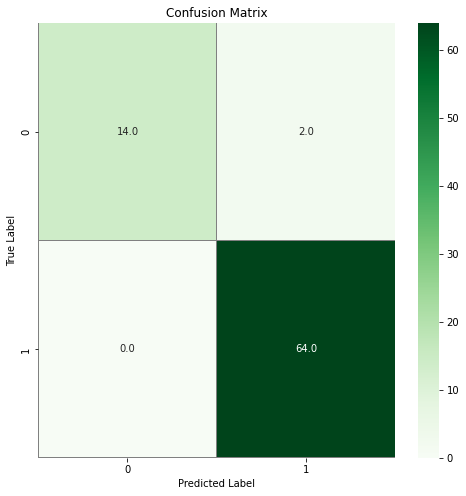

In [ ]:
# plotting result to have more insights
import seaborn as sns
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confus_res, annot=True, linewidths=0.01,cmap="Greens",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test,Y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.97      1.00      0.98        64

    accuracy                           0.97        80
   macro avg       0.98      0.94      0.96        80
weighted avg       0.98      0.97      0.97        80



In [ ]:
history = lstm_model.fit(X_train, y_train, epochs = 10, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/10
3/3 [==============================] - 7s 2s/step - loss: 0.0159 - accuracy: 0.9937 - val_loss: 0.0992 - val_accuracy: 0.9750
Epoch 2/10
3/3 [==============================] - 5s 1s/step - loss: 0.0138 - accuracy: 0.9969 - val_loss: 0.0686 - val_accuracy: 0.9875
Epoch 3/10
3/3 [==============================] - 5s 1s/step - loss: 0.0155 - accuracy: 0.9969 - val_loss: 0.0646 - val_accuracy: 0.9875
Epoch 4/10
3/3 [==============================] - 5s 2s/step - loss: 0.0138 - accuracy: 0.9969 - val_loss: 0.0712 - val_accuracy: 0.9875
Epoch 5/10
3/3 [==============================] - 5s 2s/step - loss: 0.0104 - accuracy: 0.9969 - val_loss: 0.0878 - val_accuracy: 0.9750
Epoch 6/10
3/3 [==============================] - 5s 2s/step - loss: 0.0070 - accuracy: 1.0000 - val_loss: 0.1064 - val_accuracy: 0.9750
Epoch 7/10
3/3 [==============================] - 5s 2s/step - loss: 0.0077 - accuracy: 1.0000 - val_loss: 0.1212 - val_accuracy: 0.9750
Epoch 8/10
3/3 [=========================

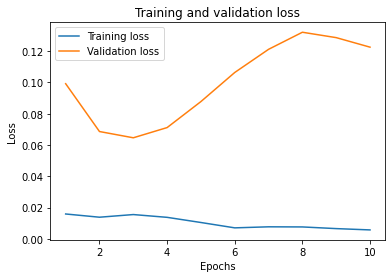

In [ ]:
# plotting the loss function to see how our model has performed
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss)+1)
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

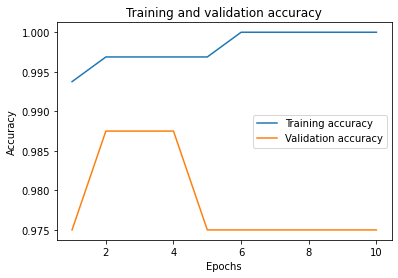

In [ ]:
# plotting the accuracy to see how our model has predicted
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
plt.plot(epochs, accuracy, label='Training accuracy')
plt.plot(epochs, val_accuracy, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show();